In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv')

# Data Exploration

In [ ]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7.0,no,no,cellular,25.0,aug,117.0,3.0,-1.0,0.0,unknown,0.0
1,1,38,blue-collar,married,secondary,no,514.0,no,no,unknown,18.0,jun,185.0,1.0,-1.0,0.0,unknown,0.0
2,2,36,blue-collar,married,secondary,no,602.0,yes,no,unknown,14.0,may,111.0,2.0,-1.0,0.0,unknown,0.0
3,3,27,student,single,secondary,no,34.0,yes,no,unknown,28.0,may,10.0,2.0,-1.0,0.0,unknown,0.0
4,4,26,technician,married,secondary,no,889.0,yes,no,cellular,3.0,feb,902.0,1.0,-1.0,0.0,unknown,1.0


In [ ]:
print(df['education'].value_counts())

education
secondary    327152
tertiary     185201
primary       81041
unknown       17329
Name: count, dtype: int64


In [ ]:
print(df['job'].value_counts())

job
management       143014
blue-collar      138834
technician       112339
admin.            66353
services          52298
retired           28716
self-employed     15521
entrepreneur      14410
unemployed        14306
housemaid         12994
student            9537
unknown            2402
Name: count, dtype: int64


In [ ]:
print(df['marital'].value_counts())

marital
married     391361
single      158708
divorced     60654
Name: count, dtype: int64


In [ ]:
print(df['contact'].value_counts())

contact
cellular     396059
unknown      188697
telephone     25967
Name: count, dtype: int64


In [ ]:
df.isna().sum()

,0
id,0
age,0
job,0
marital,1
education,1
default,1
balance,1
housing,1
loan,1
contact,1


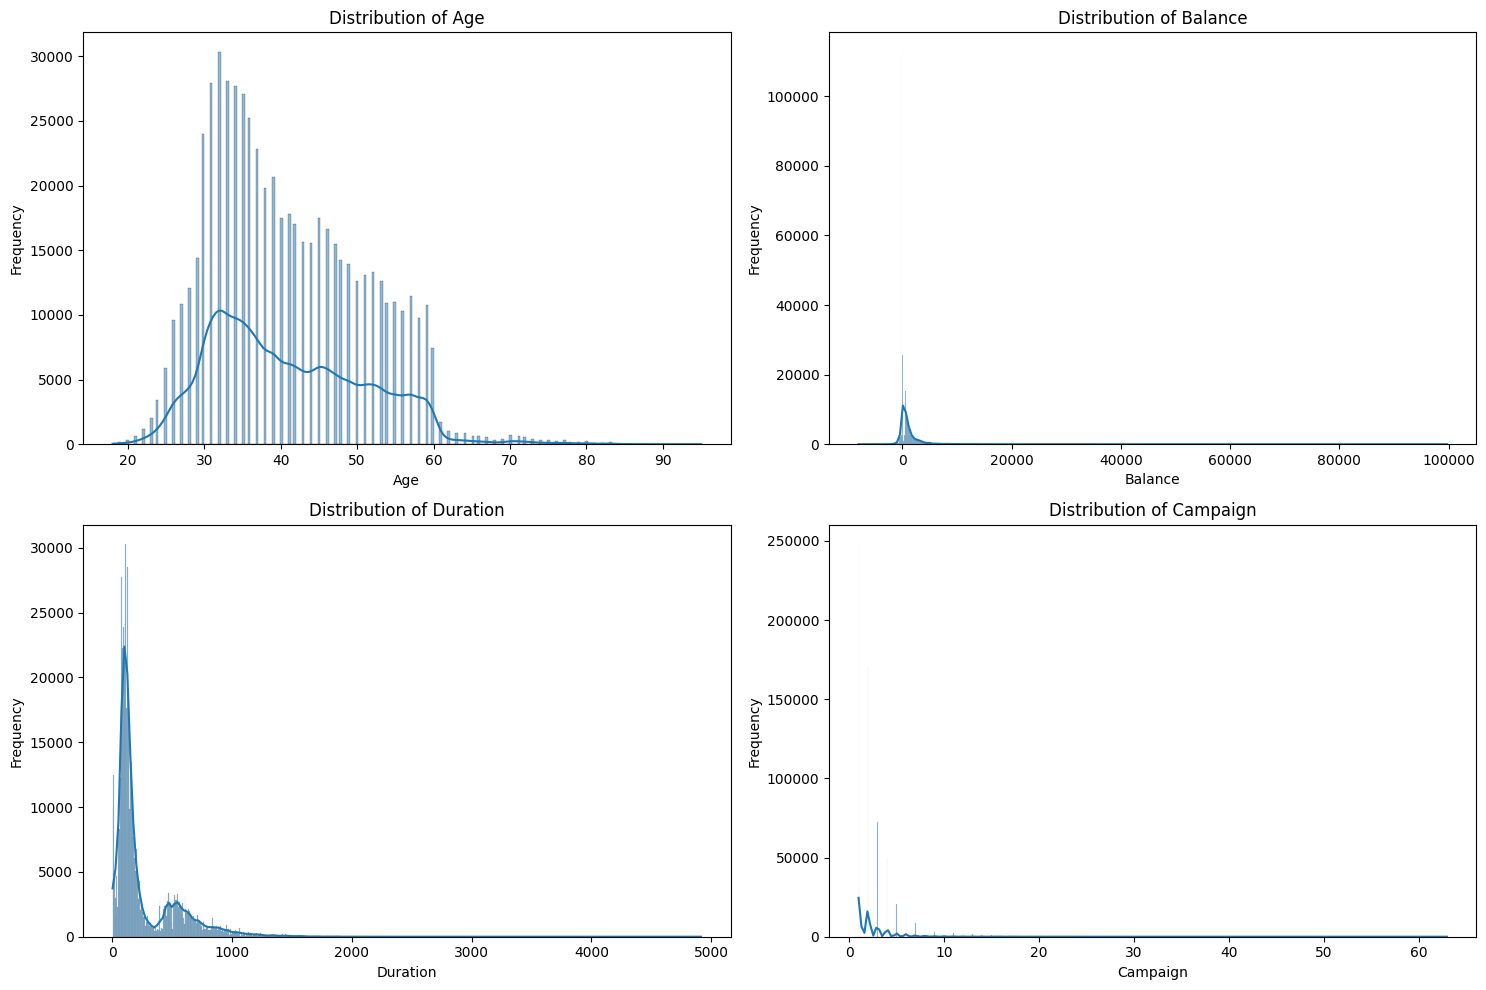

In [ ]:
columns_to_plot = ['age', 'balance', 'duration', 'campaign']

plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
def preprocess_data(df):
    df_processed = df.copy() # Work on a copy to avoid modifying original DataFrame directly

    columns_to_log = ['age', 'balance', 'duration', 'campaign']
    for col in columns_to_log:
        # Ensure values are > -1 before applying log1p to avoid errors
        # Fill NaN temporarily for log transformation if needed, then re-evaluate NaN strategy
        temp_data = df_processed[col].dropna()
        valid_for_log = temp_data[temp_data > -1]
        df_processed[f'log_{col}'] = np.nan # Initialize new column with NaNs
        df_processed.loc[valid_for_log.index, f'log_{col}'] = np.log1p(valid_for_log)

    # Remove all remaining NaN values from the DataFrame
    df_processed = df_processed.dropna()

    return df_processed

# Apply the preprocessing function
df_processed = preprocess_data(df)

print(f"Original DataFrame shape: {df.shape}")
print(f"Processed DataFrame shape: {df_processed.shape}")
display(df_processed.head())

Original DataFrame shape: (610724, 18)
Processed DataFrame shape: (525368, 22)


,id,age,job,marital,education,default,balance,housing,loan,contact,...,duration,campaign,pdays,previous,poutcome,y,log_age,log_balance,log_duration,log_campaign
0,0,42,technician,married,secondary,no,7.0,no,no,cellular,...,117.0,3.0,-1.0,0.0,unknown,0.0,3.761200,2.079442,4.770685,1.386294
1,1,38,blue-collar,married,secondary,no,514.0,no,no,unknown,...,185.0,1.0,-1.0,0.0,unknown,0.0,3.663562,6.244167,5.225747,0.693147
2,2,36,blue-collar,married,secondary,no,602.0,yes,no,unknown,...,111.0,2.0,-1.0,0.0,unknown,0.0,3.610918,6.401917,4.718499,1.098612
3,3,27,student,single,secondary,no,34.0,yes,no,unknown,...,10.0,2.0,-1.0,0.0,unknown,0.0,3.332205,3.555348,2.397895,1.098612
4,4,26,technician,married,secondary,no,889.0,yes,no,cellular,...,902.0,1.0,-1.0,0.0,unknown,1.0,3.295837,6.791221,6.805723,0.693147


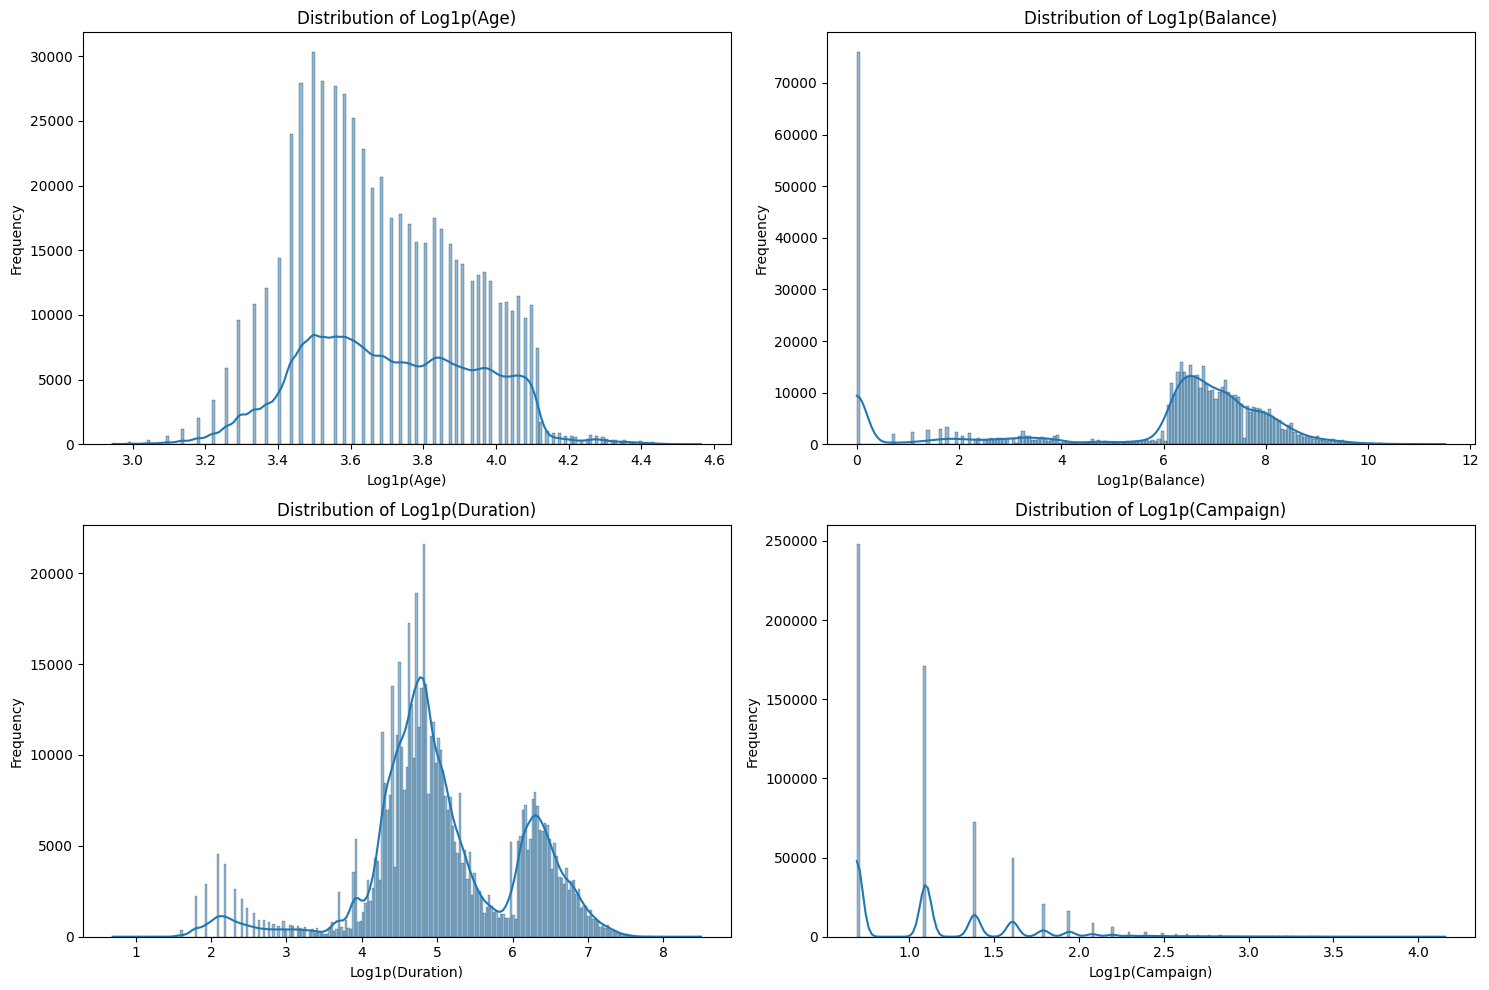

In [ ]:
columns_to_plot = ['age', 'balance', 'duration', 'campaign']

plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(2, 2, i)
    # Filter out values <= -1 before applying log1p to avoid RuntimeWarnings
    data_for_plot = df[col].dropna()
    data_for_plot = data_for_plot[data_for_plot > -1]
    sns.histplot(np.log1p(data_for_plot), kde=True)
    plt.title(f'Distribution of Log1p({col.capitalize()})')
    plt.xlabel(f'Log1p({col.capitalize()})')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Developing the model

In [ ]:
categorical_features = ['job', 'marital', 'default', 'housing', 'loan', 'month']
numerical_features = ['log_age', 'log_balance', 'log_duration', 'log_campaign']

X = df_processed[categorical_features + numerical_features]
y = df_processed['y']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print("First 5 rows of X:")
display(X.head())
print("First 5 values of y:")
display(y.head())

Shape of X: (525368, 10)
Shape of y: (525368,)
First 5 rows of X:


,job,marital,default,housing,loan,month,log_age,log_balance,log_duration,log_campaign
0,technician,married,no,no,no,aug,3.761200,2.079442,4.770685,1.386294
1,blue-collar,married,no,no,no,jun,3.663562,6.244167,5.225747,0.693147
2,blue-collar,married,no,yes,no,may,3.610918,6.401917,4.718499,1.098612
3,student,single,no,yes,no,may,3.332205,3.555348,2.397895,1.098612
4,technician,married,no,yes,no,feb,3.295837,6.791221,6.805723,0.693147


First 5 values of y:


,y
0,0.0
1,0.0
2,0.0
3,0.0
4,1.0


In [ ]:
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
X = X_encoded

print(f"Shape of X after one-hot encoding: {X.shape}")
print("First 5 rows of X after one-hot encoding:")
display(X.head())

Shape of X after one-hot encoding: (525368, 31)
First 5 rows of X after one-hot encoding:


,log_age,log_balance,log_duration,log_campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,3.761200,2.079442,4.770685,1.386294,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3.663562,6.244167,5.225747,0.693147,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,3.610918,6.401917,4.718499,1.098612,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,3.332205,3.555348,2.397895,1.098612,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,3.295837,6.791221,6.805723,0.693147,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("First 5 rows of X_train:")
display(X_train.head())
print("First 5 values of y_train:")
display(y_train.head())

Shape of X_train: (420294, 31)
Shape of X_test: (105074, 31)
Shape of y_train: (420294,)
Shape of y_test: (105074,)
First 5 rows of X_train:


,log_age,log_balance,log_duration,log_campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
57023,3.295837,0.000000,6.068426,1.386294,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
396930,3.465736,6.678342,6.248043,1.386294,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
368401,3.583519,0.000000,5.099866,1.386294,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
392352,3.931826,0.000000,4.844187,1.098612,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
356240,3.583519,8.486322,3.610918,3.135494,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


First 5 values of y_train:


,y
57023,0.0
396930,0.0
368401,1.0
392352,0.0
356240,0.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc_model = DecisionTreeClassifier(random_state=42)

# Train the model using the training data
dtc_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [ ]:
y_pred = dtc_model.predict(X_test)
y_pred_proba = dtc_model.predict_proba(X_test)[:, 1]

print(f"Shape of y_pred: {y_pred.shape}")
print("First 5 predicted classes (y_pred):")
display(y_pred[:5])
print("First 5 predicted probabilities (y_pred_proba):")
display(y_pred_proba[:5])

Shape of y_pred: (105074,)
First 5 predicted classes (y_pred):


array([0., 0., 0., 0., 1.])

First 5 predicted probabilities (y_pred_proba):


array([0., 0., 0., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluation metrics and visualization libraries imported successfully.")

Evaluation metrics and visualization libraries imported successfully.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8792
Precision: 0.5543
Recall: 0.5702
F1-Score: 0.5622


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93     90782
         1.0       0.55      0.57      0.56     14292

    accuracy                           0.88    105074
   macro avg       0.74      0.75      0.75    105074
weighted avg       0.88      0.88      0.88    105074



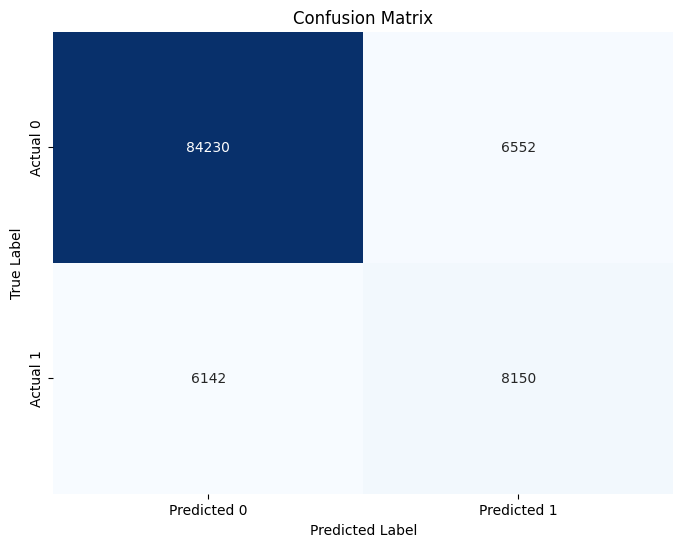

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


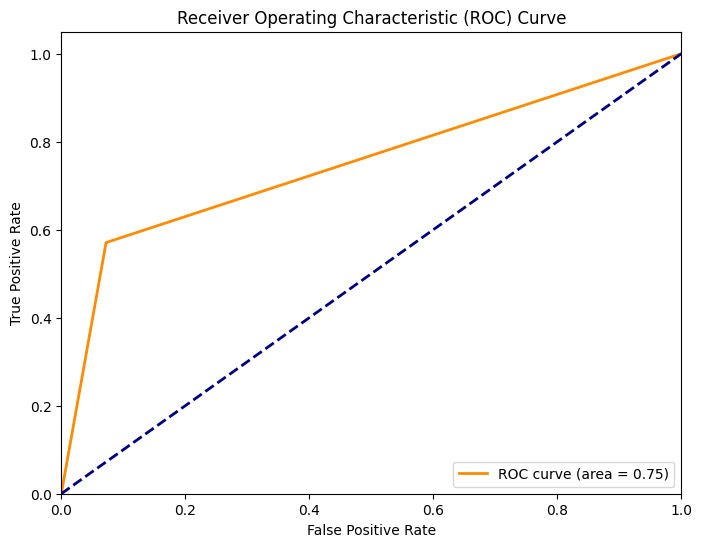

ROC AUC Score: 0.7493


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

## Summary of Model Performance

The Decision Tree Classifier achieved the following performance metrics on the test set:

- **Accuracy**: 0.8792
- **Precision (Class 1)**: 0.5543
- **Recall (Class 1)**: 0.5702
- **F1-Score (Class 1)**: 0.5622
- **ROC AUC Score**: 0.7493


The confusion matrix visually confirms this, showing a notable number of false negatives (actual 1s predicted as 0s) and false positives (actual 0s predicted as 1s) for class 1, although false negatives are higher. The ROC curve with an AUC score of 0.7493 indicates a moderately good ability of the model to distinguish between the two classes, but there is room for improvement, especially concerning the prediction of the minority class.

In [ ]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of X_resampled: {X_resampled.shape}")
print(f"Shape of y_resampled: {y_resampled.shape}")
print("Class distribution of y_resampled:")
print(y_resampled.value_counts())

Shape of X_resampled: (726092, 31)
Shape of y_resampled: (726092,)
Class distribution of y_resampled:
y
0.0    363046
1.0    363046
Name: count, dtype: int64


# Training Decision Tree Model on Balanced Data



In [ ]:
dtc_model_resampled = DecisionTreeClassifier(random_state=42)
dtc_model_resampled.fit(X_resampled, y_resampled)

print("Decision Tree Classifier trained successfully on resampled data.")

Decision Tree Classifier trained successfully on resampled data.


In [ ]:
y_pred_resampled = dtc_model_resampled.predict(X_test)
y_pred_proba_resampled = dtc_model_resampled.predict_proba(X_test)[:, 1]

print(f"Shape of y_pred_resampled: {y_pred_resampled.shape}")
print("First 5 predicted classes (y_pred_resampled):")
display(y_pred_resampled[:5])
print("First 5 predicted probabilities (y_pred_proba_resampled):")
display(y_pred_proba_resampled[:5])

Shape of y_pred_resampled: (105074,)
First 5 predicted classes (y_pred_resampled):


array([0., 0., 0., 0., 0.])

First 5 predicted probabilities (y_pred_proba_resampled):


array([0., 0., 0., 0., 0.])

In [ ]:
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled)
recall_resampled = recall_score(y_test, y_pred_resampled)
f1_resampled = f1_score(y_test, y_pred_resampled)

print(f"Accuracy (Resampled Model): {accuracy_resampled:.4f}")
print(f"Precision (Resampled Model): {precision_resampled:.4f}")
print(f"Recall (Resampled Model): {recall_resampled:.4f}")
print(f"F1-Score (Resampled Model): {f1_resampled:.4f}")

Accuracy (Resampled Model): 0.8657
Precision (Resampled Model): 0.5048
Recall (Resampled Model): 0.6537
F1-Score (Resampled Model): 0.5697


In [ ]:
print("Classification Report (Resampled Model):")
print(classification_report(y_test, y_pred_resampled))

Classification Report (Resampled Model):
              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92     90782
         1.0       0.50      0.65      0.57     14292

    accuracy                           0.87    105074
   macro avg       0.72      0.78      0.75    105074
weighted avg       0.88      0.87      0.87    105074



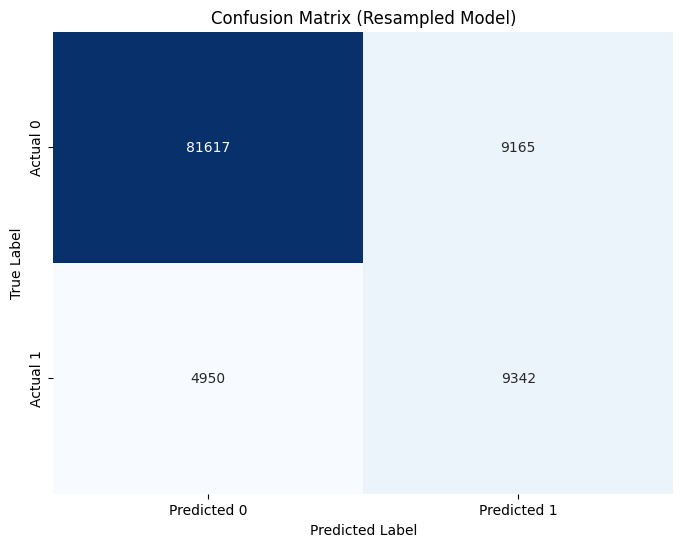

In [ ]:
cm_resampled = confusion_matrix(y_test, y_pred_resampled)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Resampled Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

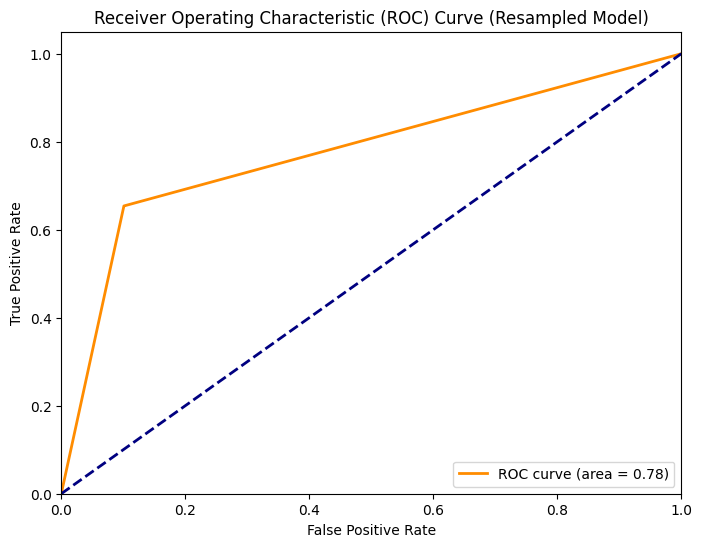

ROC AUC Score (Resampled Model): 0.7765


In [ ]:
fpr_resampled, tpr_resampled, thresholds_resampled = roc_curve(y_test, y_pred_proba_resampled)
roc_auc_resampled = auc(fpr_resampled, tpr_resampled)

plt.figure(figsize=(8, 6))
plt.plot(fpr_resampled, tpr_resampled, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_resampled:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Resampled Model)')
plt.legend(loc='lower right')
plt.show()

print(f"ROC AUC Score (Resampled Model): {roc_auc_resampled:.4f}")

# Retraining Random Forest Model with K-fold cross validation



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

print("RandomForestClassifier initialized successfully.")

RandomForestClassifier initialized successfully.


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
roc_auc_scores = cross_val_score(rf_model, X_resampled, y_resampled, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"ROC AUC scores for each fold: {roc_auc_scores}")
print(f"Mean ROC AUC: {roc_auc_scores.mean():.4f}")
print(f"Standard Deviation of ROC AUC: {roc_auc_scores.std():.4f}")

ROC AUC scores for each fold: [0.98436445 0.98343515 0.98365251 0.98394283 0.98383553]
Mean ROC AUC: 0.9838
Standard Deviation of ROC AUC: 0.0003


In [ ]:
rf_model.fit(X_resampled, y_resampled)

print("Final Random Forest model trained successfully on resampled data.")

Final Random Forest model trained successfully on resampled data.


In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Shape of y_pred_rf: {y_pred_rf.shape}")
print("First 5 predicted classes (y_pred_rf):")
display(y_pred_rf[:5])
print("First 5 predicted probabilities (y_pred_proba_rf):")
display(y_pred_proba_rf[:5])

Shape of y_pred_rf: (105074,)
First 5 predicted classes (y_pred_rf):


array([0., 0., 0., 0., 1.])

First 5 predicted probabilities (y_pred_proba_rf):


array([0.  , 0.13, 0.12, 0.  , 0.8 ])

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy (Random Forest Model): {accuracy_rf:.4f}")
print(f"Precision (Random Forest Model): {precision_rf:.4f}")
print(f"Recall (Random Forest Model): {recall_rf:.4f}")
print(f"F1-Score (Random Forest Model): {f1_rf:.4f}")

Accuracy (Random Forest Model): 0.8908
Precision (Random Forest Model): 0.5752
Recall (Random Forest Model): 0.7538
F1-Score (Random Forest Model): 0.6525


In [ ]:
print("Classification Report (Random Forest Model):")
print(classification_report(y_test, y_pred_rf))

Classification Report (Random Forest Model):
              precision    recall  f1-score   support

         0.0       0.96      0.91      0.94     90782
         1.0       0.58      0.75      0.65     14292

    accuracy                           0.89    105074
   macro avg       0.77      0.83      0.79    105074
weighted avg       0.91      0.89      0.90    105074



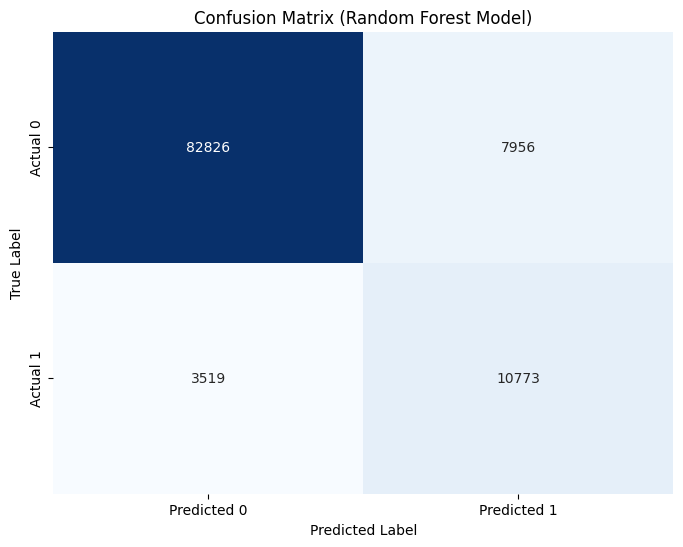

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Random Forest Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

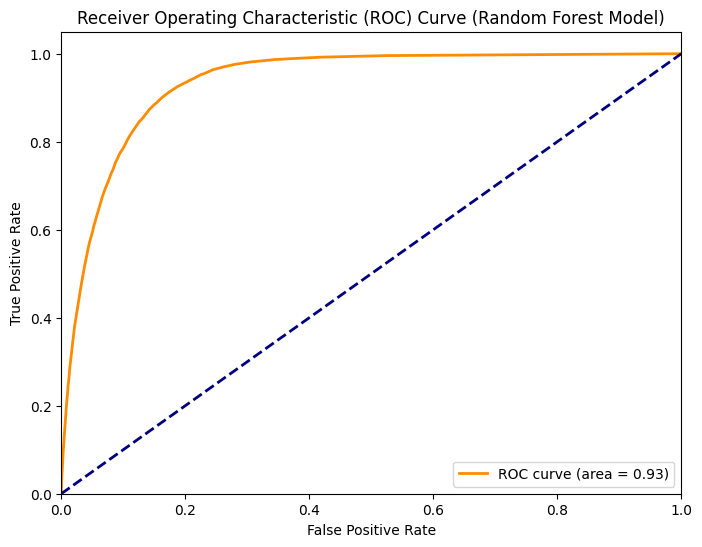

ROC AUC Score (Random Forest Model): 0.9349


In [ ]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Random Forest Model)')
plt.legend(loc='lower right')
plt.show()

print(f"ROC AUC Score (Random Forest Model): {roc_auc_rf:.4f}")

# Testing and exporting submission.csv

In [ ]:
df_test = pd.read_csv('test.csv')
df_test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [ ]:
def preprocess_data(df, is_test=False):
    df_processed = df.copy() # Work on a copy to avoid modifying original DataFrame directly

    # Numerical columns for imputation and log transformation
    numerical_cols_impute_log = ['age', 'balance', 'duration', 'campaign']
    # Additional numerical columns for imputation only (not log-transformed)
    numerical_cols_impute_only = ['day', 'pdays', 'previous']

    # Categorical columns for imputation
    categorical_cols_impute = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
    # Only include 'y' if it's not the test set
    if not is_test:
        categorical_cols_impute.append('y')

    # Impute missing numerical values with the mean
    for col in numerical_cols_impute_log + numerical_cols_impute_only:
        if df_processed[col].isnull().any():
            mean_value = df_processed[col].mean()
            df_processed[col] = df_processed[col].fillna(mean_value)

    # Impute missing categorical values with the mode
    for col in categorical_cols_impute:
        if df_processed[col].isnull().any():
            # Use .mode()[0] to get the first mode in case of multiple modes
            mode_value = df_processed[col].mode()[0]
            df_processed[col] = df_processed[col].fillna(mode_value)

    # Apply log1p transformation to specified numerical columns
    for col in numerical_cols_impute_log:
        # Ensure values are >= -1 before applying log1p
        # Add 1 to any negative values to make them 0 before log1p
        # This handles -1 for 'pdays' and other potential negatives, ensuring log1p(0) for -1 original
        # For other columns like 'balance', 'age', duration, campaign, it's not expected to be negative, but better safe
        df_processed[f'log_{col}'] = df_processed[col].apply(lambda x: np.log1p(x) if x > -1 else np.log1p(0))

    return df_processed

# Apply the new preprocessing function for training data to re-establish df_processed correctly
df_processed = preprocess_data(df, is_test=False)

print(f"New shape of df_processed: {df_processed.shape}")
display(df_processed.head())

New shape of df_processed: (610724, 22)


,id,age,job,marital,education,default,balance,housing,loan,contact,...,duration,campaign,pdays,previous,poutcome,y,log_age,log_balance,log_duration,log_campaign
0,0,42,technician,married,secondary,no,7.0,no,no,cellular,...,117.0,3.0,-1.0,0.0,unknown,0.0,3.761200,2.079442,4.770685,1.386294
1,1,38,blue-collar,married,secondary,no,514.0,no,no,unknown,...,185.0,1.0,-1.0,0.0,unknown,0.0,3.663562,6.244167,5.225747,0.693147
2,2,36,blue-collar,married,secondary,no,602.0,yes,no,unknown,...,111.0,2.0,-1.0,0.0,unknown,0.0,3.610918,6.401917,4.718499,1.098612
3,3,27,student,single,secondary,no,34.0,yes,no,unknown,...,10.0,2.0,-1.0,0.0,unknown,0.0,3.332205,3.555348,2.397895,1.098612
4,4,26,technician,married,secondary,no,889.0,yes,no,cellular,...,902.0,1.0,-1.0,0.0,unknown,1.0,3.295837,6.791221,6.805723,0.693147


In [ ]:
df_test_processed = preprocess_data(df_test, is_test=True)

# Get IDs from the processed test data before encoding to use them in the submission file
test_ids_final = df_test_processed['id']

# Select the features for the test set. These are the same numerical features defined earlier.
# For categorical features, we will use the list of categorical_features defined for the training set

X_test_submission_raw = df_test_processed[categorical_features + numerical_features]

# Apply one-hot encoding to categorical features in test data, similar to how X was encoded
X_test_submission_encoded = pd.get_dummies(X_test_submission_raw, columns=categorical_features, drop_first=True)

# Align columns with the training data (X) to ensure consistent features
# X was the final encoded training data after one-hot encoding
train_cols_final = X.columns

X_test_submission = X_test_submission_encoded.reindex(columns=train_cols_final, fill_value=0)

print(f"Shape of X_test_submission after preprocessing and alignment: {X_test_submission.shape}")
print("First 5 rows of X_test_submission:")
display(X_test_submission.head())

Shape of X_test_submission after preprocessing and alignment: (250000, 42)
First 5 rows of X_test_submission:


,log_age,log_balance,log_duration,log_campaign,day,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,3.496508,7.242798,5.416100,0.693147,21,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
1,3.806662,3.178054,6.375025,1.098612,3,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3.610918,3.850148,4.718499,1.098612,13,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,4.077537,0.000000,4.836282,0.693147,29,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,3.367296,7.576097,5.204007,0.693147,22,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True


In [ ]:
predictions_proba_final = rf_model_new.predict_proba(X_test_submission)[:, 1]
predictions_binary = (predictions_proba_final >= optimal_threshold).astype(int)

submission_df_final = pd.DataFrame({'id': test_ids_final, 'y': predictions_binary})

# Save the submission file
submission_df_final.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
print("First 5 rows of the submission file:")
display(submission_df_final.head())
print(f"Total rows in submission file: {submission_df_final.shape[0]}")

Submission file 'submission.csv' created successfully.
First 5 rows of the submission file:


,id,y
0,750000,0
1,750001,0
2,750002,0
3,750003,0
4,750004,0


Total rows in submission file: 250000
